In [45]:
import os, sys
from pathlib import Path

# 1) Find repo root by locating src/features/glove.py (works even if kernel starts in C:\Users)
start = Path.cwd().resolve()
glove_py = next(iter(start.rglob("src/features/glove.py")), None)
if glove_py is None:
    for parent in start.parents:
        glove_py = next(iter(parent.rglob("src/features/glove.py")), None)
        if glove_py:
            break
assert glove_py is not None, "Repo root not found (src/features/glove.py missing)."

REPO = glove_py.parents[2]
os.chdir(REPO)
sys.path.insert(0, str(REPO))

# 2) Find GloVe inside notebooks/
GLOVE_TXT = next(iter((Path.cwd() / "notebooks").rglob("glove.6B.100d.txt")), None)
assert GLOVE_TXT is not None, "Missing notebooks/glove.6B.100d.txt"

print("Repo:", Path.cwd())
print("GloVe:", GLOVE_TXT)





Repo: C:\Users\nikoma\Movie-review-emotion-classifier
GloVe: C:\Users\nikoma\Movie-review-emotion-classifier\notebooks\glove.6B.100d.txt


In [46]:
from src.features.glove import build_glove_features, sequences_to_vectors

X_train_seq, y_train_glove, X_test_seq, y_test_glove, tokenizer, embedding_matrix, num_words = build_glove_features(
    glove_path=str(GLOVE_TXT)
)


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [48]:
from src.features.glove import (
    build_glove_tokenizer_and_matrix,
    build_glove_features,
    sequences_to_vectors,
)

X_train_seq, y_train_glove, X_test_seq, y_test_glove, tokenizer, embedding_matrix, num_words = build_glove_features(glove_path=str(GLOVE_TXT))
print("Train seq:", X_train_seq.shape)
print("Test seq: ", X_test_seq.shape)
print("Embedding:", embedding_matrix.shape)
print("num_words:", num_words)


Train seq: (16000, 100)
Test seq:  (2000, 100)
Embedding: (15214, 100)
num_words: 15214


In [50]:
X_train_seq, y_train_glove, X_test_seq, y_test_glove, tokenizer, embedding_matrix, _ = build_glove_features(
    glove_path=str(GLOVE_TXT)
)

X_train_glove = sequences_to_vectors(X_train_seq, embedding_matrix)
X_test_glove  = sequences_to_vectors(X_test_seq, embedding_matrix)

print("GloVe Train:", X_train_glove.shape)
print("GloVe Test: ", X_test_glove.shape)


GloVe Train: (16000, 201)
GloVe Test:  (2000, 201)


In [51]:
scaler = StandardScaler()
X_train_glove_scaled = scaler.fit_transform(X_train_glove)
X_test_glove_scaled  = scaler.transform(X_test_glove)

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    "LogisticRegression": LogisticRegression(
        C=10.0, max_iter=2000, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "SVM_RBF": SVC(
        kernel="rbf", C=50.0, gamma="scale", class_weight="balanced", 
        probability=True, random_state=42
    ),
    "LinearSVM": LinearSVC(
        C=1.0, class_weight="balanced", max_iter=2000, random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=20, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "KNeighbors": KNeighborsClassifier(
        n_neighbors=15, weights="distance", n_jobs=-1
    ),
    "GaussianNB": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, eval_metric="mlogloss"
    )
}

print("Models:", list(classifiers.keys()))


Models: ['LogisticRegression', 'SVM_RBF', 'LinearSVM', 'DecisionTree', 'RandomForest', 'KNeighbors', 'GaussianNB', 'XGBoost']


Logistic Regression
Accuracy: 0.5410, F1: 0.5587

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.45      0.56       581
           1       0.75      0.58      0.65       695
           2       0.33      0.62      0.43       159
           3       0.46      0.55      0.50       275
           4       0.47      0.56      0.51       224
           5       0.21      0.65      0.32        66

    accuracy                           0.54      2000
   macro avg       0.49      0.57      0.49      2000
weighted avg       0.62      0.54      0.56      2000



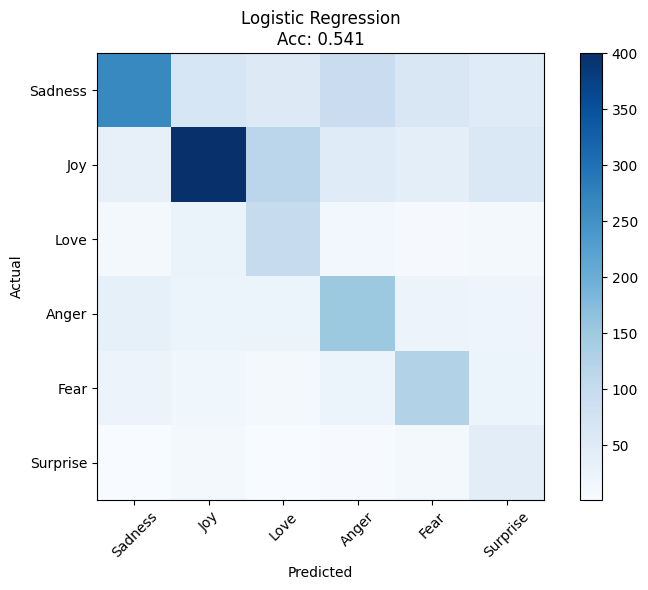

In [53]:
# Logistic Regression
lr_clf = LogisticRegression(
    C=10.0, max_iter=2000, class_weight="balanced", random_state=42, n_jobs=-1
)
lr_clf.fit(X_train_glove_scaled, y_train_glove)
y_pred_lr = lr_clf.predict(X_test_glove_scaled)

acc_lr = accuracy_score(y_test_glove, y_pred_lr)
f1_lr = f1_score(y_test_glove, y_pred_lr, average="weighted")

print(f"Logistic Regression")
print(f"Accuracy: {acc_lr:.4f}, F1: {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_glove, y_pred_lr)
plt.figure(figsize=(8, 6))
plt.imshow(cm_lr, cmap="Blues")
plt.title(f"Logistic Regression\nAcc: {acc_lr:.3f}")
plt.colorbar()
emotion_names = ["Sadness", "Joy", "Love", "Anger", "Fear", "Surprise"]
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


SVM RBF
Accuracy: 0.6535, F1: 0.6452

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       581
           1       0.68      0.80      0.73       695
           2       0.54      0.37      0.44       159
           3       0.64      0.56      0.59       275
           4       0.58      0.51      0.54       224
           5       0.49      0.30      0.37        66

    accuracy                           0.65      2000
   macro avg       0.60      0.54      0.56      2000
weighted avg       0.65      0.65      0.65      2000



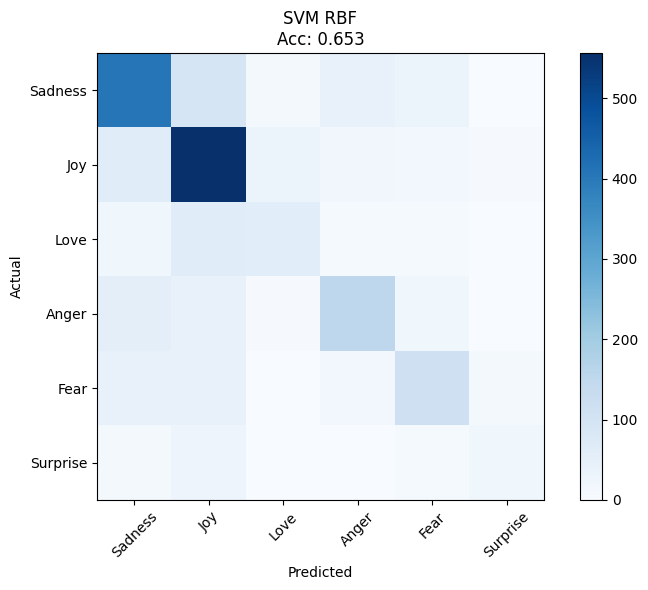

In [54]:
# SVM RBF
svm_rbf = SVC(
    kernel="rbf", C=50.0, gamma="scale", class_weight="balanced", 
    probability=True, random_state=42
)
svm_rbf.fit(X_train_glove_scaled, y_train_glove)
y_pred_svm = svm_rbf.predict(X_test_glove_scaled)

acc_svm = accuracy_score(y_test_glove, y_pred_svm)
f1_svm = f1_score(y_test_glove, y_pred_svm, average="weighted")

print(f"SVM RBF")
print(f"Accuracy: {acc_svm:.4f}, F1: {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_glove, y_pred_svm)
plt.figure(figsize=(8, 6))
plt.imshow(cm_svm, cmap="Blues")
plt.title(f"SVM RBF\nAcc: {acc_svm:.3f}")
plt.colorbar()
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Random Forest
Accuracy: 0.5405, F1: 0.4763

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.65      0.58       581
           1       0.53      0.88      0.66       695
           2       0.65      0.08      0.15       159
           3       0.80      0.12      0.21       275
           4       0.75      0.18      0.29       224
           5       0.60      0.09      0.16        66

    accuracy                           0.54      2000
   macro avg       0.64      0.33      0.34      2000
weighted avg       0.60      0.54      0.48      2000



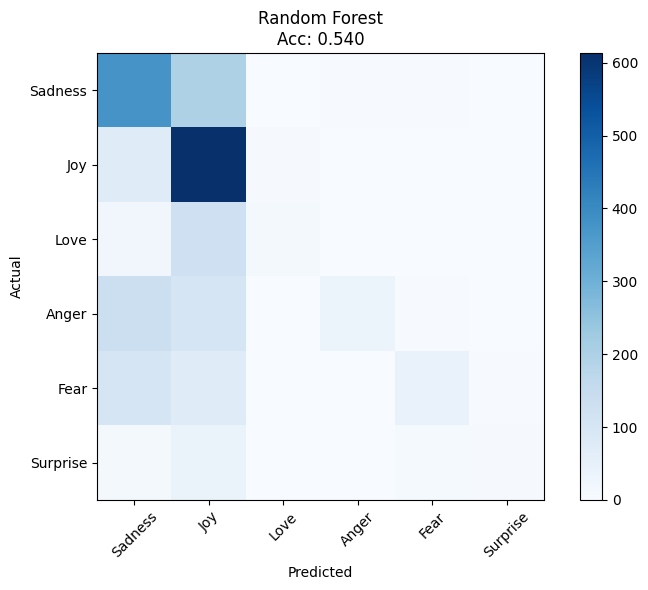

In [55]:
# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=20, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_glove_scaled, y_train_glove)
y_pred_rf = rf_clf.predict(X_test_glove_scaled)

acc_rf = accuracy_score(y_test_glove, y_pred_rf)
f1_rf = f1_score(y_test_glove, y_pred_rf, average="weighted")

print(f"Random Forest")
print(f"Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test_glove, y_pred_rf)
plt.figure(figsize=(8, 6))
plt.imshow(cm_rf, cmap="Blues")
plt.title(f"Random Forest\nAcc: {acc_rf:.3f}")
plt.colorbar()
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


XGBoost
Accuracy: 0.7475, F1: 0.7421

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       581
           1       0.71      0.86      0.78       695
           2       0.72      0.50      0.59       159
           3       0.83      0.65      0.73       275
           4       0.82      0.64      0.72       224
           5       0.74      0.44      0.55        66

    accuracy                           0.75      2000
   macro avg       0.76      0.65      0.69      2000
weighted avg       0.75      0.75      0.74      2000



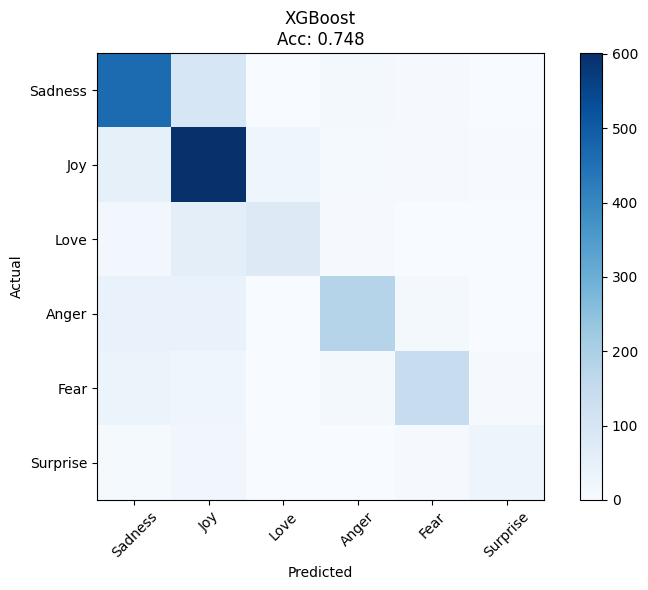

In [56]:
# XGBoost
xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric="mlogloss"
)
xgb_clf.fit(X_train_glove_scaled, y_train_glove)
y_pred_xgb = xgb_clf.predict(X_test_glove_scaled)

acc_xgb = accuracy_score(y_test_glove, y_pred_xgb)
f1_xgb = f1_score(y_test_glove, y_pred_xgb, average="weighted")

print(f"XGBoost")
print(f"Accuracy: {acc_xgb:.4f}, F1: {f1_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_glove, y_pred_xgb)
plt.figure(figsize=(8, 6))
plt.imshow(cm_xgb, cmap="Blues")
plt.title(f"XGBoost\nAcc: {acc_xgb:.3f}")
plt.colorbar()
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Gaussian Naive Bayes
Accuracy: 0.3425, F1: 0.3628

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.36      0.39       581
           1       0.59      0.40      0.48       695
           2       0.13      0.53      0.20       159
           3       0.45      0.13      0.21       275
           4       0.32      0.26      0.29       224
           5       0.17      0.26      0.20        66

    accuracy                           0.34      2000
   macro avg       0.35      0.32      0.29      2000
weighted avg       0.44      0.34      0.36      2000



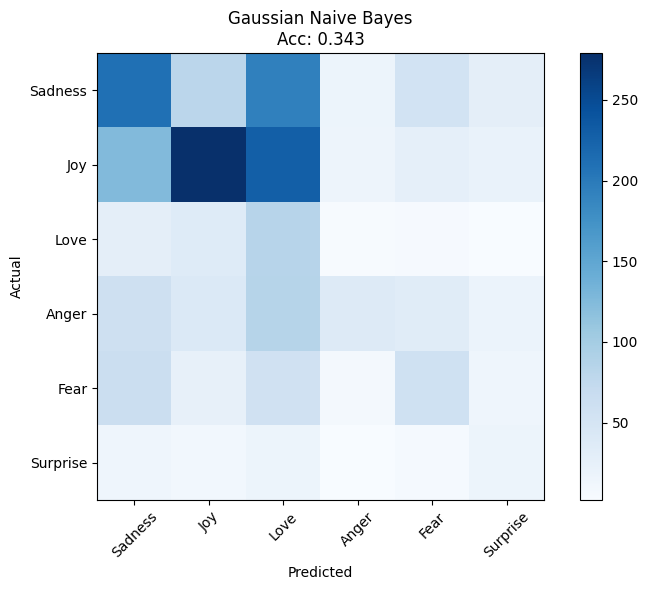

In [57]:
# Gaussian Naive Bayes (uses UNSCALED features)
nb_clf = GaussianNB()
nb_clf.fit(X_train_glove, y_train_glove)  # Unscaled!
y_pred_nb = nb_clf.predict(X_test_glove)   # Unscaled!

acc_nb = accuracy_score(y_test_glove, y_pred_nb)
f1_nb = f1_score(y_test_glove, y_pred_nb, average="weighted")

print(f"Gaussian Naive Bayes")
print(f"Accuracy: {acc_nb:.4f}, F1: {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test_glove, y_pred_nb)
plt.figure(figsize=(8, 6))
plt.imshow(cm_nb, cmap="Blues")
plt.title(f"Gaussian Naive Bayes\nAcc: {acc_nb:.3f}")
plt.colorbar()
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


K-Nearest Neighbors
Accuracy: 0.4855, F1: 0.4480

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.61      0.51       581
           1       0.55      0.72      0.62       695
           2       0.53      0.11      0.19       159
           3       0.41      0.20      0.27       275
           4       0.38      0.20      0.26       224
           5       0.60      0.05      0.08        66

    accuracy                           0.49      2000
   macro avg       0.48      0.31      0.32      2000
weighted avg       0.48      0.49      0.45      2000



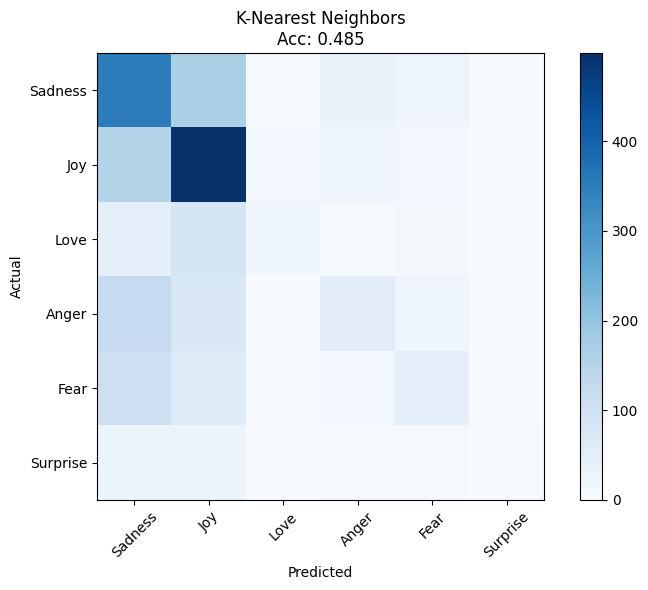

In [58]:
# K-Nearest Neighbors
knn_clf = KNeighborsClassifier(
    n_neighbors=15, weights="distance", n_jobs=-1
)
knn_clf.fit(X_train_glove_scaled, y_train_glove)
y_pred_knn = knn_clf.predict(X_test_glove_scaled)

acc_knn = accuracy_score(y_test_glove, y_pred_knn)
f1_knn = f1_score(y_test_glove, y_pred_knn, average="weighted")

print(f"K-Nearest Neighbors")
print(f"Accuracy: {acc_knn:.4f}, F1: {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_glove, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test_glove, y_pred_knn)
plt.figure(figsize=(8, 6))
plt.imshow(cm_knn, cmap="Blues")
plt.title(f"K-Nearest Neighbors\nAcc: {acc_knn:.3f}")
plt.colorbar()
plt.xticks(np.arange(6), emotion_names, rotation=45)
plt.yticks(np.arange(6), emotion_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
